# Focal Loss Reproduction on Imbalanced CIFAR-10

This notebook presents a tiny reproduction of focal loss under class imbalance.

## Key Experiments
- Cross-Entropy vs Focal Loss (γ)
- Effect of α reweighting
- Evaluation using Minority Accuracy and Macro-F1

## How to Run
Run all cells from top to bottom. CIFAR-10 will be downloaded automatically.
Final results are shown in the last section.

## 1. Imports and Global Settings

In [1]:
import json, os, random, copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt

MAJ = {0,1,2,3,4}
MIN = {5,6,7,8,9}

In [2]:
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def make_deterministic(seed: int, deterministic: bool = True):
    set_global_seed(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## 2. Imbalanced CIFAR-10 Dataset

In [3]:
def build_transforms():
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2023, 0.1994, 0.2010)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, test_tf

In [4]:
def make_imbalanced_indices(y, ratio: float, seed: int):
    rng = np.random.default_rng(seed)
    keep = {0:1,1:1,2:1,3:1,4:1,5:ratio,6:ratio,7:ratio,8:ratio,9:ratio}

    idx = []
    for c in range(10):
        ids = np.where(y == c)[0]
        rng.shuffle(ids)
        idx.append(ids[: int(len(ids) * keep[c])])
    return np.concatenate(idx)

def build_loaders(root="./data", batch=256, ratio=0.1, seed=0, num_workers=2):
    train_tf, test_tf = build_transforms()

    train_full = CIFAR10(root, train=True, download=True, transform=train_tf)
    y = np.array(train_full.targets)
    idx = make_imbalanced_indices(y, ratio=ratio, seed=seed)
    train_ds = Subset(train_full, idx)

    test_ds = CIFAR10(root, train=False, download=True, transform=test_tf)  # balanced test

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=batch, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        worker_init_fn=seed_worker, generator=g
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    return train_loader, test_loader

## 3. Model and Loss Functions

In [5]:
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * loss

        return loss.mean()

def build_loss(method: str, gamma: float = 2.0, alpha=None):
    if method == "ce":
        return lambda logits, y: F.cross_entropy(logits, y)
    if method == "focal":
        return FocalLoss(gamma=gamma, alpha=alpha)
    raise ValueError("method must be 'ce' or 'focal'")

In [6]:
def build_model(num_classes=10):
    return resnet18(num_classes=num_classes)

def get_init_state(seed: int):
    make_deterministic(seed, deterministic=True)
    m = build_model()
    return copy.deepcopy(m.state_dict())

## 4. Training and Evaluation Functions

In [7]:
@torch.no_grad()
def eval_metrics(model, loader, device):
    model.eval()

    correct = 0; total = 0
    per_cls_correct = [0]*10
    per_cls_total = [0]*10
    per_cls_pred = [0]*10

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()

        for c in range(10):
            m = (y == c)
            per_cls_total[c] += m.sum().item()
            per_cls_correct[c] += ((pred == y) & m).sum().item()
            per_cls_pred[c] += (pred == c).sum().item()

    overall = correct / max(1, total)
    per_cls_acc = [(per_cls_correct[c] / max(1, per_cls_total[c])) for c in range(10)]
    minority = sum(per_cls_acc[c] for c in MIN) / len(MIN)
    majority = sum(per_cls_acc[c] for c in MAJ) / len(MAJ)

    per_cls_f1 = []
    for c in range(10):
        TP = per_cls_correct[c]
        FP = per_cls_pred[c] - TP
        FN = per_cls_total[c] - TP
        precision = TP / max(1, (TP + FP))
        recall    = TP / max(1, (TP + FN))
        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * precision * recall / (precision + recall)
        per_cls_f1.append(f1)
    macro_f1 = sum(per_cls_f1) / len(per_cls_f1)

    return overall, minority, majority, macro_f1

In [8]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))

## 5. Experiment Setup

In [9]:
def run_experiment(method="ce", gamma=2.0, alpha=None, epochs=30, lr=0.1, ratio=0.05, seed=0, batch=256,
                   init_state=None, deterministic=True):
    make_deterministic(seed, deterministic=deterministic)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    if alpha is not None:
      alpha = alpha.to(device)

    train_loader, test_loader = build_loaders(batch=batch, ratio=ratio, seed=seed)

    model = build_model().to(device)
    if init_state is not None:
        model.load_state_dict(copy.deepcopy(init_state))

    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    loss_fn = build_loss(method, gamma=gamma, alpha=alpha)

    hist = []
    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, opt, loss_fn, device)
        overall, minority, majority, macro_f1 = eval_metrics(model, test_loader, device)
        hist.append({"epoch": ep, "train_loss": tr_loss,
                     "overall_acc": overall, "minority_acc": minority, "majority_acc": majority, "macro_f1": macro_f1})
        if ep % 30 == 0:
          if alpha is None:
              alpha_str = ""
          else:
              alpha_str = f", alpha={int(alpha.max().item())}"

          gamma_str = f", gamma={gamma}" if method == "focal" else ""

          print(
              f"[{method}{gamma_str}{alpha_str}] "
              f"ep={ep:02d} "
              f"loss={tr_loss:.4f} "
              f"overall={overall:.4f} "
              f"minority={minority:.4f} "
              f"majority={majority:.4f} "
              f"macroF1={macro_f1:.4f}"
          )
    return hist

In [ ]:
def fair_gamma_sweep(gammas=(0.0, 1.0, 2.0), seeds=(0,1,2), epochs=30, lr=0.1, ratio=0.05, batch=256):
    rows = []
    curves = {}

    for s in seeds:
        print(f"-------- seed={s} --------")
        init_state = get_init_state(seed=s)

        # CE
        ce = run_experiment("ce", epochs=epochs, lr=lr, ratio=ratio, seed=s, batch=batch, init_state=init_state)
        rows.append(("CE", np.nan, s, ce[-1]["overall_acc"], ce[-1]["majority_acc"], ce[-1]["minority_acc"], ce[-1]["macro_f1"]))
        curves.setdefault(("CE", np.nan), []).append([h["macro_f1"] for h in ce])

        # Focal for each gamma
        for g in gammas:
            # Focal without alpha
            fo = run_experiment("focal", gamma=g, epochs=epochs, lr=lr, ratio=ratio,
                                seed=s, batch=batch, init_state=init_state, alpha=None)
            rows.append(("Focal", g, s,
                        fo[-1]["overall_acc"],
                        fo[-1]["majority_acc"],
                        fo[-1]["minority_acc"],
                        fo[-1]["macro_f1"]))
            curves.setdefault(("Focal", g), []).append([h["macro_f1"] for h in fo])

            # Focal with alpha=25
            alpha_tensor = torch.tensor([1,1,1,1,1,25,25,25,25,25], dtype=torch.float32)
            fo_a = run_experiment("focal", gamma=g, epochs=epochs, lr=lr, ratio=ratio,
                                  seed=s, batch=batch, init_state=init_state,
                                  alpha=alpha_tensor)
            rows.append(("Focal+α=25", g, s,
                        fo_a[-1]["overall_acc"],
                        fo_a[-1]["majority_acc"],
                        fo_a[-1]["minority_acc"],
                        fo_a[-1]["macro_f1"]))
            curves.setdefault(("Focal+α=25", g), []).append([h["macro_f1"] for h in fo_a])

            # Focal with alpha=10
            alpha_tensor_10 = torch.tensor([1,1,1,1,1,10,10,10,10,10], dtype=torch.float32)
            fo_a10 = run_experiment("focal", gamma=g, epochs=epochs, lr=lr, ratio=ratio,
                                    seed=s, batch=batch, init_state=init_state,
                                    alpha=alpha_tensor_10)

            rows.append(("Focal+α=10", g, s,
                        fo_a10[-1]["overall_acc"],
                        fo_a10[-1]["majority_acc"],
                        fo_a10[-1]["minority_acc"],
                        fo_a10[-1]["macro_f1"]))

            curves.setdefault(("Focal+α=10", g), []).append([h["macro_f1"] for h in fo_a10])

    return rows, curves


# ---- run ----
EPOCHS = 30
rows, curves = fair_gamma_sweep(
    gammas=(1.0, 2.0),
    seeds=(0,1,2),
    epochs=EPOCHS,
    lr=0.1,
    ratio=0.02,
    batch=256
)

## 6. Results

The following table summarizes the final performance across methods.

In [11]:
def summarize_rows(rows):
    df = pd.DataFrame(rows, columns=["method","gamma","seed","overall","majority","minority","macroF1"])

    summary = df.groupby(["method","gamma"], dropna=False).agg(
        minority_mean=("minority","mean"),
        macroF1_mean=("macroF1","mean"),
        minority_std=("minority","std"),
        macroF1_std=("macroF1","std")
    ).reset_index()

    summary["Minority Acc"] = summary.apply(
        lambda x: f"{x['minority_mean']:.3f} ± {x['minority_std']:.3f}", axis=1
    )
    summary["Macro-F1"] = summary.apply(
        lambda x: f"{x['macroF1_mean']:.3f} ± {x['macroF1_std']:.3f}", axis=1
    )

    def format_method(row):
      if row["method"] == "CE":
          return "CE"
      else:
          return f"{row['method']} (γ={row['gamma']})"

    summary["Method"] = summary.apply(format_method, axis=1)

    final_table = summary[["Method", "Minority Acc", "Macro-F1"]]

    return df, final_table

df_all, df_summary = summarize_rows(rows)
df_summary

,Method,Minority Acc,Macro-F1
0,CE,0.071 ± 0.028,0.342 ± 0.033
1,Focal (γ=1.0),0.089 ± 0.045,0.354 ± 0.038
2,Focal (γ=2.0),0.056 ± 0.017,0.320 ± 0.020
3,Focal+α=10 (γ=1.0),0.299 ± 0.089,0.472 ± 0.052
4,Focal+α=10 (γ=2.0),0.252 ± 0.063,0.425 ± 0.042
5,Focal+α=25 (γ=1.0),0.216 ± 0.188,0.288 ± 0.118
6,Focal+α=25 (γ=2.0),0.276 ± 0.110,0.324 ± 0.036


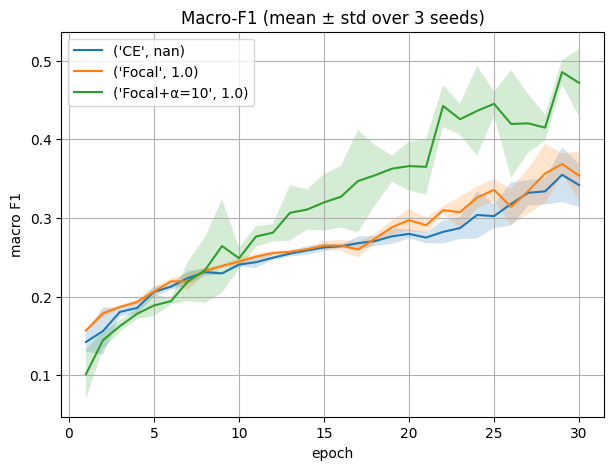

In [12]:
def plot_mean_std(curves, label_key, epochs):
    arr = np.array(curves[label_key], dtype=float)
    m = arr.mean(axis=0)
    s = arr.std(axis=0)
    x = np.arange(1, epochs+1)
    plt.plot(x, m, label=f"{label_key}")
    plt.fill_between(x, m-s, m+s, alpha=0.2)

epochs = len(curves[("CE", np.nan)][0])

plt.figure(figsize=(7,5))

plot_mean_std(curves, ("CE", np.nan), epochs)
plot_mean_std(curves, ("Focal", 1.0), epochs)
plot_mean_std(curves, ("Focal+α=10", 1.0), epochs)

plt.xlabel("epoch")
plt.ylabel("macro F1")
plt.title("Macro-F1 (mean ± std over 3 seeds)")
plt.legend()
plt.grid(True)
plt.show()

## 7. Conclusion

- Focal Loss (γ=1) improves over Cross-Entropy
- Larger γ degrades performance
- Moderate α improves both minority accuracy and macro-F1
- Large α leads to overcompensation